# Crowded Condition — Baseline vs Fine-tuned Comparison

Mirrors **DarkCondition_Comparison.ipynb** for the crowded scenario.

| | Baseline | Fine-tuned |
|---|---|---|
| Weights | yolov8n_llvip_person/best.pt | yolov8_mot17_finetune_from_llvip/best.pt |
| Training | Dark (LLVIP) only | Dark + Crowded (LLVIP → MOT17) |

**Memory fix:** raw frames are NOT cached in RAM across thresholds.  
Only the single threshold used for visuals (0.35) re-reads frames from disk on demand.

### Confirmed GT metrics from crowdedCondition.ipynb
| Metric | BEFORE | AFTER | Change |
|---|---|---|---|
| Precision   | 0.797 | **0.970** | +17.3 pp |
| Recall      | 0.541 | **0.888** | +34.7 pp |
| mAP\@0.5    | 0.662 | **0.964** | +30.2 pp |
| mAP\@0.5-95 | 0.384 | **0.759** | +37.5 pp |

## 0) Dependencies

In [ ]:
# !pip install -q ultralytics opencv-python numpy pandas matplotlib

## 1) Configuration

In [1]:
import os, gc, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

# ── EDIT THESE ──────────────────────────────────────────────────────
MOT17_ROOT        = '../MOT17'
VAL_SEQUENCES     = ['MOT17-04-FRCNN', 'MOT17-09-FRCNN']

BASELINE_WEIGHTS  = 'runs/darkCondition_yolo/runs/yolov8n_llvip_person/weights/best.pt'
FINETUNED_WEIGHTS = r'runs\detect\runs\crowdedCondition_yolo\runs\yolov8_mot17_finetune_from_llvip\weights\best.pt'

OUTPUT_DIR        = 'outputs/crowded_comparison'
os.makedirs(OUTPUT_DIR, exist_ok=True)

THRESHOLDS        = [0.25, 0.35, 0.50]
VIS_THRESH        = 0.35   # threshold used for visuals + video
SAVE_VIDEO        = True
MAX_FRAMES_PER_SEQ = None  # set e.g. 300 for a quick test

# ── Verify ──────────────────────────────────────────────────────────
for p in [BASELINE_WEIGHTS, FINETUNED_WEIGHTS]:
    print(f'  {"✅" if os.path.exists(p) else "❌ NOT FOUND"}  {p}')
print()
for seq in VAL_SEQUENCES:
    img_dir = Path(MOT17_ROOT) / 'train' / seq / 'img1'
    n = len(list(img_dir.glob('*.jpg'))) if img_dir.exists() else 0
    print(f'  {"✅" if img_dir.exists() else "❌ NOT FOUND"}  {seq}  ({n} frames)')

  ✅  runs/darkCondition_yolo/runs/yolov8n_llvip_person/weights/best.pt
  ✅  runs\detect\runs\crowdedCondition_yolo\runs\yolov8_mot17_finetune_from_llvip\weights\best.pt

  ✅  MOT17-04-FRCNN  (1050 frames)
  ✅  MOT17-09-FRCNN  (525 frames)


## 2) Core Detection Runner

In [2]:
def run_detection_on_sequences(sequences, mot17_root, weights,
                               conf_threshold,
                               max_frames_per_seq=None,
                               store_frames=False):
    """
    Runs YOLO person detection on all val sequence frames.

    store_frames : if False (default), raw_frames list is empty — saves ~30 GB RAM.
                   Set True only for the one threshold you need for visuals.
    Returns (records, raw_frames, img_paths)
      records   : [{seq, frame_id, count, boxes}]
      raw_frames: list of BGR frames (empty when store_frames=False)
      img_paths : list of Path objects (always populated, used for on-demand reads)
    """
    model      = YOLO(weights)
    records    = []
    raw_frames = []
    img_paths  = []

    for seq in sequences:
        img_dir = Path(mot17_root) / 'train' / seq / 'img1'
        imgs    = sorted(img_dir.glob('*.jpg'))
        if not imgs:
            imgs = sorted(img_dir.glob('*.png'))
        if max_frames_per_seq:
            imgs = imgs[:max_frames_per_seq]

        for img_path in imgs:
            frame = cv2.imread(str(img_path))
            if frame is None:
                continue

            res = model(frame, conf=conf_threshold, classes=[0], verbose=False)[0]
            boxes = []
            if res.boxes is not None:
                for b in res.boxes:
                    x1,y1,x2,y2 = b.xyxy[0].cpu().numpy().astype(int)
                    boxes.append((x1, y1, x2, y2, float(b.conf[0])))

            records.append({'seq': seq, 'frame_id': int(img_path.stem),
                            'count': len(boxes), 'boxes': boxes})
            img_paths.append(img_path)

            if store_frames:
                raw_frames.append(frame)

            # Free the frame from memory immediately when not storing
            del frame

    print(f'  Done: {len(records)} frames | model={Path(weights).name} | '
          f'conf={conf_threshold} | frames cached: {len(raw_frames)}')
    return records, raw_frames, img_paths

## 3) Run Both Models Across All Thresholds

For 0.25 and 0.50: only detection records are stored (no frames → tiny RAM use).  
For 0.35 (VIS_THRESH): frames ARE cached — used for side-by-side samples and video.

In [3]:
results_store = {}   # thresh -> {baseline: (records, raw_frames, img_paths), finetuned: ...}

for thresh in THRESHOLDS:
    need_frames = (thresh == VIS_THRESH)
    print(f'\n── Threshold: {thresh} '
          f'({"caching frames for visuals" if need_frames else "counts only — no frame cache"}) ──')
    results_store[thresh] = {}

    print('  [Baseline — LLVIP only]')
    rec_b, frm_b, pth_b = run_detection_on_sequences(
        VAL_SEQUENCES, MOT17_ROOT, BASELINE_WEIGHTS,
        thresh, MAX_FRAMES_PER_SEQ, store_frames=need_frames)
    results_store[thresh]['baseline'] = (rec_b, frm_b, pth_b)

    print('  [Fine-tuned — LLVIP + MOT17]')
    rec_f, frm_f, pth_f = run_detection_on_sequences(
        VAL_SEQUENCES, MOT17_ROOT, FINETUNED_WEIGHTS,
        thresh, MAX_FRAMES_PER_SEQ, store_frames=need_frames)
    results_store[thresh]['finetuned'] = (rec_f, frm_f, pth_f)

    gc.collect()   # release any lingering GPU/CPU memory after each threshold

print('\n✅ All sweeps complete.')


── Threshold: 0.25 (counts only — no frame cache) ──
  [Baseline — LLVIP only]
  Done: 1575 frames | model=best.pt | conf=0.25 | frames cached: 0
  [Fine-tuned — LLVIP + MOT17]
  Done: 1575 frames | model=best.pt | conf=0.25 | frames cached: 0

── Threshold: 0.35 (caching frames for visuals) ──
  [Baseline — LLVIP only]
  Done: 1575 frames | model=best.pt | conf=0.35 | frames cached: 1575
  [Fine-tuned — LLVIP + MOT17]
  Done: 1575 frames | model=best.pt | conf=0.35 | frames cached: 1575

── Threshold: 0.5 (counts only — no frame cache) ──
  [Baseline — LLVIP only]
  Done: 1575 frames | model=best.pt | conf=0.5 | frames cached: 0
  [Fine-tuned — LLVIP + MOT17]
  Done: 1575 frames | model=best.pt | conf=0.5 | frames cached: 0

✅ All sweeps complete.


## 4) Summary Metrics Table

In [4]:
rows = []
for thresh in THRESHOLDS:
    for key, label in [('baseline','Baseline (LLVIP only)'),
                       ('finetuned','Fine-tuned (LLVIP+MOT17)')]:
        records,_,_ = results_store[thresh][key]
        counts = [r['count'] for r in records]
        rows.append({
            'Threshold'          : thresh,
            'Model'              : label,
            'Avg Det/Frame'      : round(np.mean(counts), 3),
            'Max Det/Frame'      : int(np.max(counts)),
            'Zero-Det Frames'    : int(np.sum(np.array(counts)==0)),
            'Zero-Det Frames (%)': round(100*np.sum(np.array(counts)==0)/len(counts), 1),
            'Total Detections'   : int(np.sum(counts)),
        })

df_summary = pd.DataFrame(rows)

impr_rows = []
for thresh in THRESHOLDS:
    b = df_summary[(df_summary.Threshold==thresh)&(df_summary.Model.str.contains('Baseline'))]['Avg Det/Frame'].values[0]
    f = df_summary[(df_summary.Threshold==thresh)&(df_summary.Model.str.contains('Fine'))  ]['Avg Det/Frame'].values[0]
    impr_rows.append({'Threshold': thresh, 'Improvement %': round((f-b)/max(b,1e-6)*100, 1)})

df_impr = pd.DataFrame(impr_rows)

print('=== Per-Model Summary ===')
print(df_summary.to_string(index=False))
print()
print('=== Improvement of Fine-tuned over Baseline (Avg Det/Frame) ===')
print(df_impr.to_string(index=False))

df_summary.to_csv(os.path.join(OUTPUT_DIR,'summary.csv'),     index=False)
df_impr.to_csv(   os.path.join(OUTPUT_DIR,'improvement.csv'), index=False)
print('\nSaved CSVs to:', OUTPUT_DIR)

=== Per-Model Summary ===
 Threshold                    Model  Avg Det/Frame  Max Det/Frame  Zero-Det Frames  Zero-Det Frames (%)  Total Detections
      0.25    Baseline (LLVIP only)         18.457             38                0                  0.0             29069
      0.25 Fine-tuned (LLVIP+MOT17)         35.269             60                0                  0.0             55549
      0.35    Baseline (LLVIP only)         16.703             33                0                  0.0             26307
      0.35 Fine-tuned (LLVIP+MOT17)         32.697             56                0                  0.0             51498
      0.50    Baseline (LLVIP only)         14.319             28                0                  0.0             22552
      0.50 Fine-tuned (LLVIP+MOT17)         30.335             49                0                  0.0             47778

=== Improvement of Fine-tuned over Baseline (Avg Det/Frame) ===
 Threshold  Improvement %
      0.25           91.1
   

## 5) Per-Frame Detection Count Chart

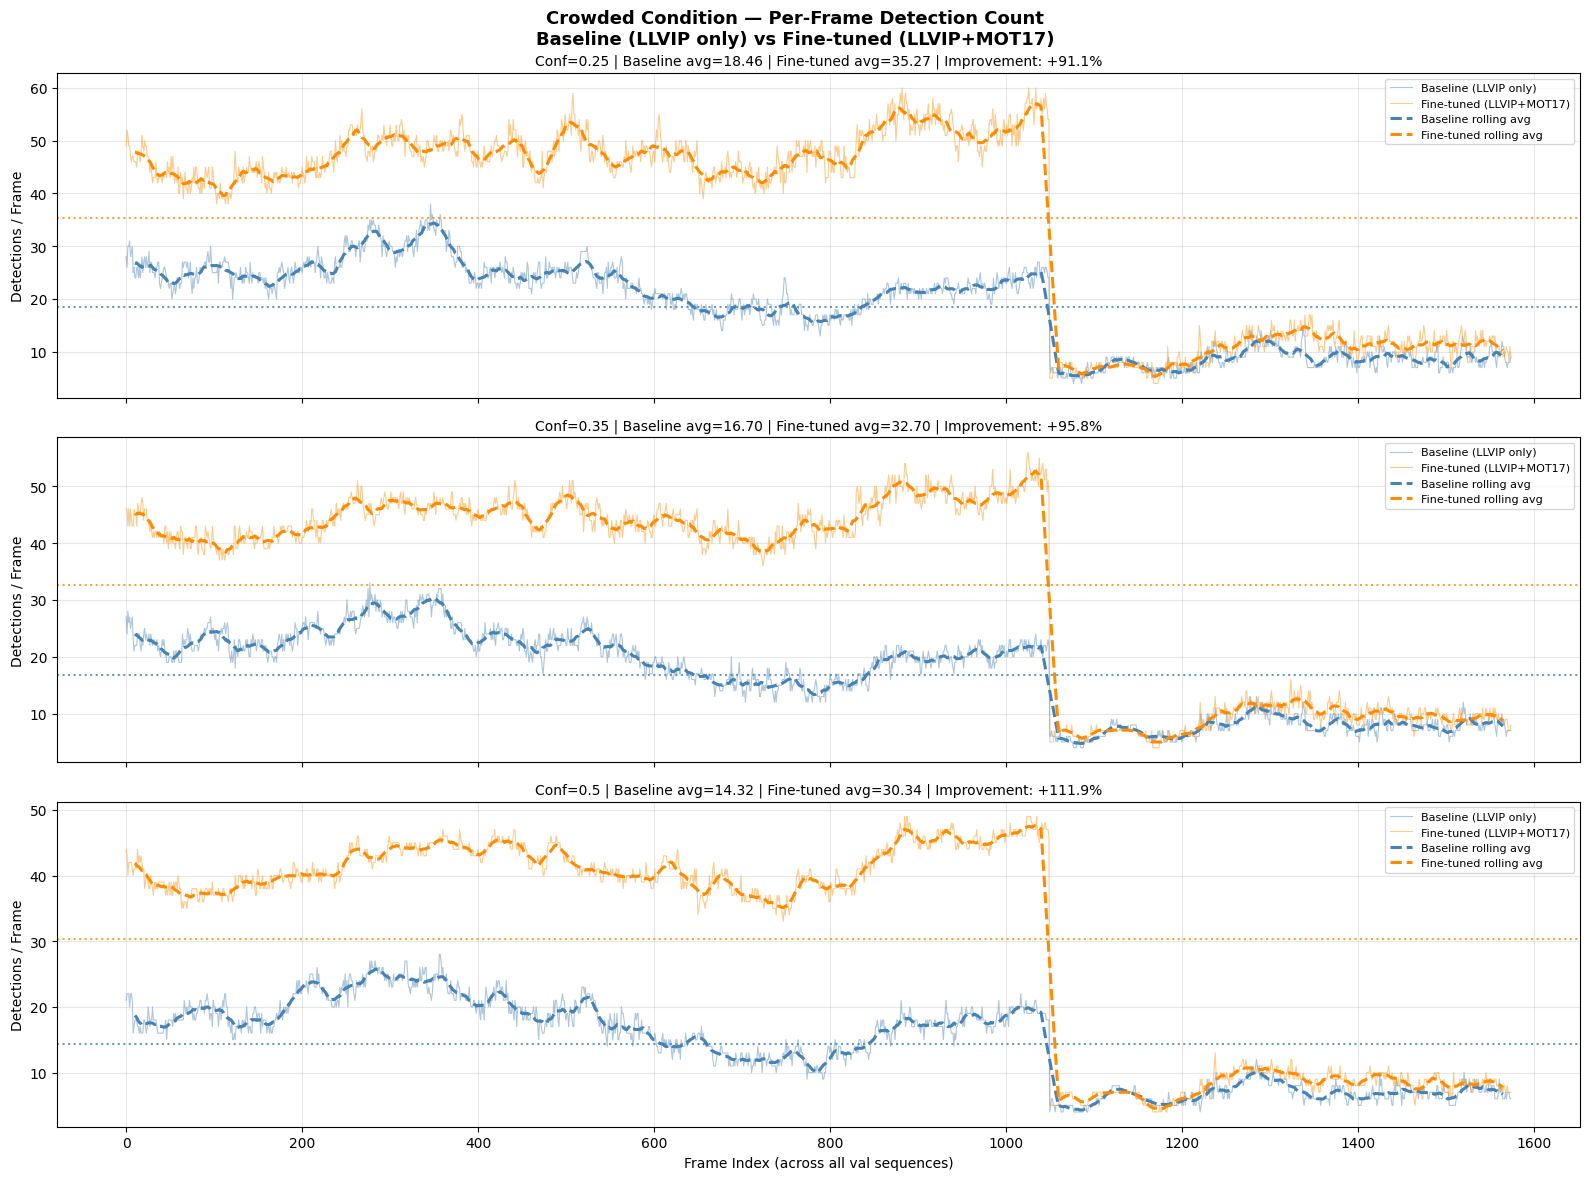

Saved chart to: outputs/crowded_comparison\detection_count_chart.png


In [5]:
COLOR_B = 'steelblue'
COLOR_F = 'darkorange'

fig, axes = plt.subplots(len(THRESHOLDS), 1,
                         figsize=(16, 4*len(THRESHOLDS)), sharex=True)
if len(THRESHOLDS)==1: axes=[axes]

for ax, thresh in zip(axes, THRESHOLDS):
    rec_b,_,_ = results_store[thresh]['baseline']
    rec_f,_,_ = results_store[thresh]['finetuned']
    fids = list(range(len(rec_b)))
    cb   = [r['count'] for r in rec_b]
    cf   = [r['count'] for r in rec_f]

    ax.plot(fids, cb, color=COLOR_B, alpha=0.45, linewidth=0.8,
            label='Baseline (LLVIP only)')
    ax.plot(fids, cf, color=COLOR_F, alpha=0.45, linewidth=0.8,
            label='Fine-tuned (LLVIP+MOT17)')

    win = 20
    if len(cb) > win:
        rb = pd.Series(cb).rolling(win, center=True).mean()
        rf = pd.Series(cf).rolling(win, center=True).mean()
        ax.plot(fids, rb, color=COLOR_B, linewidth=2.2, linestyle='--',
                label=f'Baseline rolling avg')
        ax.plot(fids, rf, color=COLOR_F, linewidth=2.2, linestyle='--',
                label=f'Fine-tuned rolling avg')

    avg_b, avg_f = np.mean(cb), np.mean(cf)
    imp  = (avg_f-avg_b)/max(avg_b,1e-6)*100
    sign = '+' if imp>=0 else ''
    ax.axhline(avg_b, color=COLOR_B, linewidth=1.5, linestyle=':', alpha=0.8)
    ax.axhline(avg_f, color=COLOR_F, linewidth=1.5, linestyle=':', alpha=0.8)
    ax.set_title(f'Conf={thresh} | Baseline avg={avg_b:.2f} | '
                 f'Fine-tuned avg={avg_f:.2f} | Improvement: {sign}{imp:.1f}%',
                 fontsize=10)
    ax.set_ylabel('Detections / Frame')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Frame Index (across all val sequences)')
plt.suptitle('Crowded Condition — Per-Frame Detection Count\n'
             'Baseline (LLVIP only) vs Fine-tuned (LLVIP+MOT17)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
out = os.path.join(OUTPUT_DIR,'detection_count_chart.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Saved chart to:', out)

## 6) Side-by-Side Frame Samples

Picks the 4 frames where fine-tuned detects the most extra persons.  
Frames are read from disk on demand — no extra RAM needed.

Top disagreement frames (conf=0.35):
  idx=  831 | seq=MOT17-04-FRCNN | baseline=15 fine-tuned=50 (+35)
  idx= 1025 | seq=MOT17-04-FRCNN | baseline=21 fine-tuned=56 (+35)
  idx=  775 | seq=MOT17-04-FRCNN | baseline=12 fine-tuned=46 (+34)
  idx=  830 | seq=MOT17-04-FRCNN | baseline=15 fine-tuned=49 (+34)


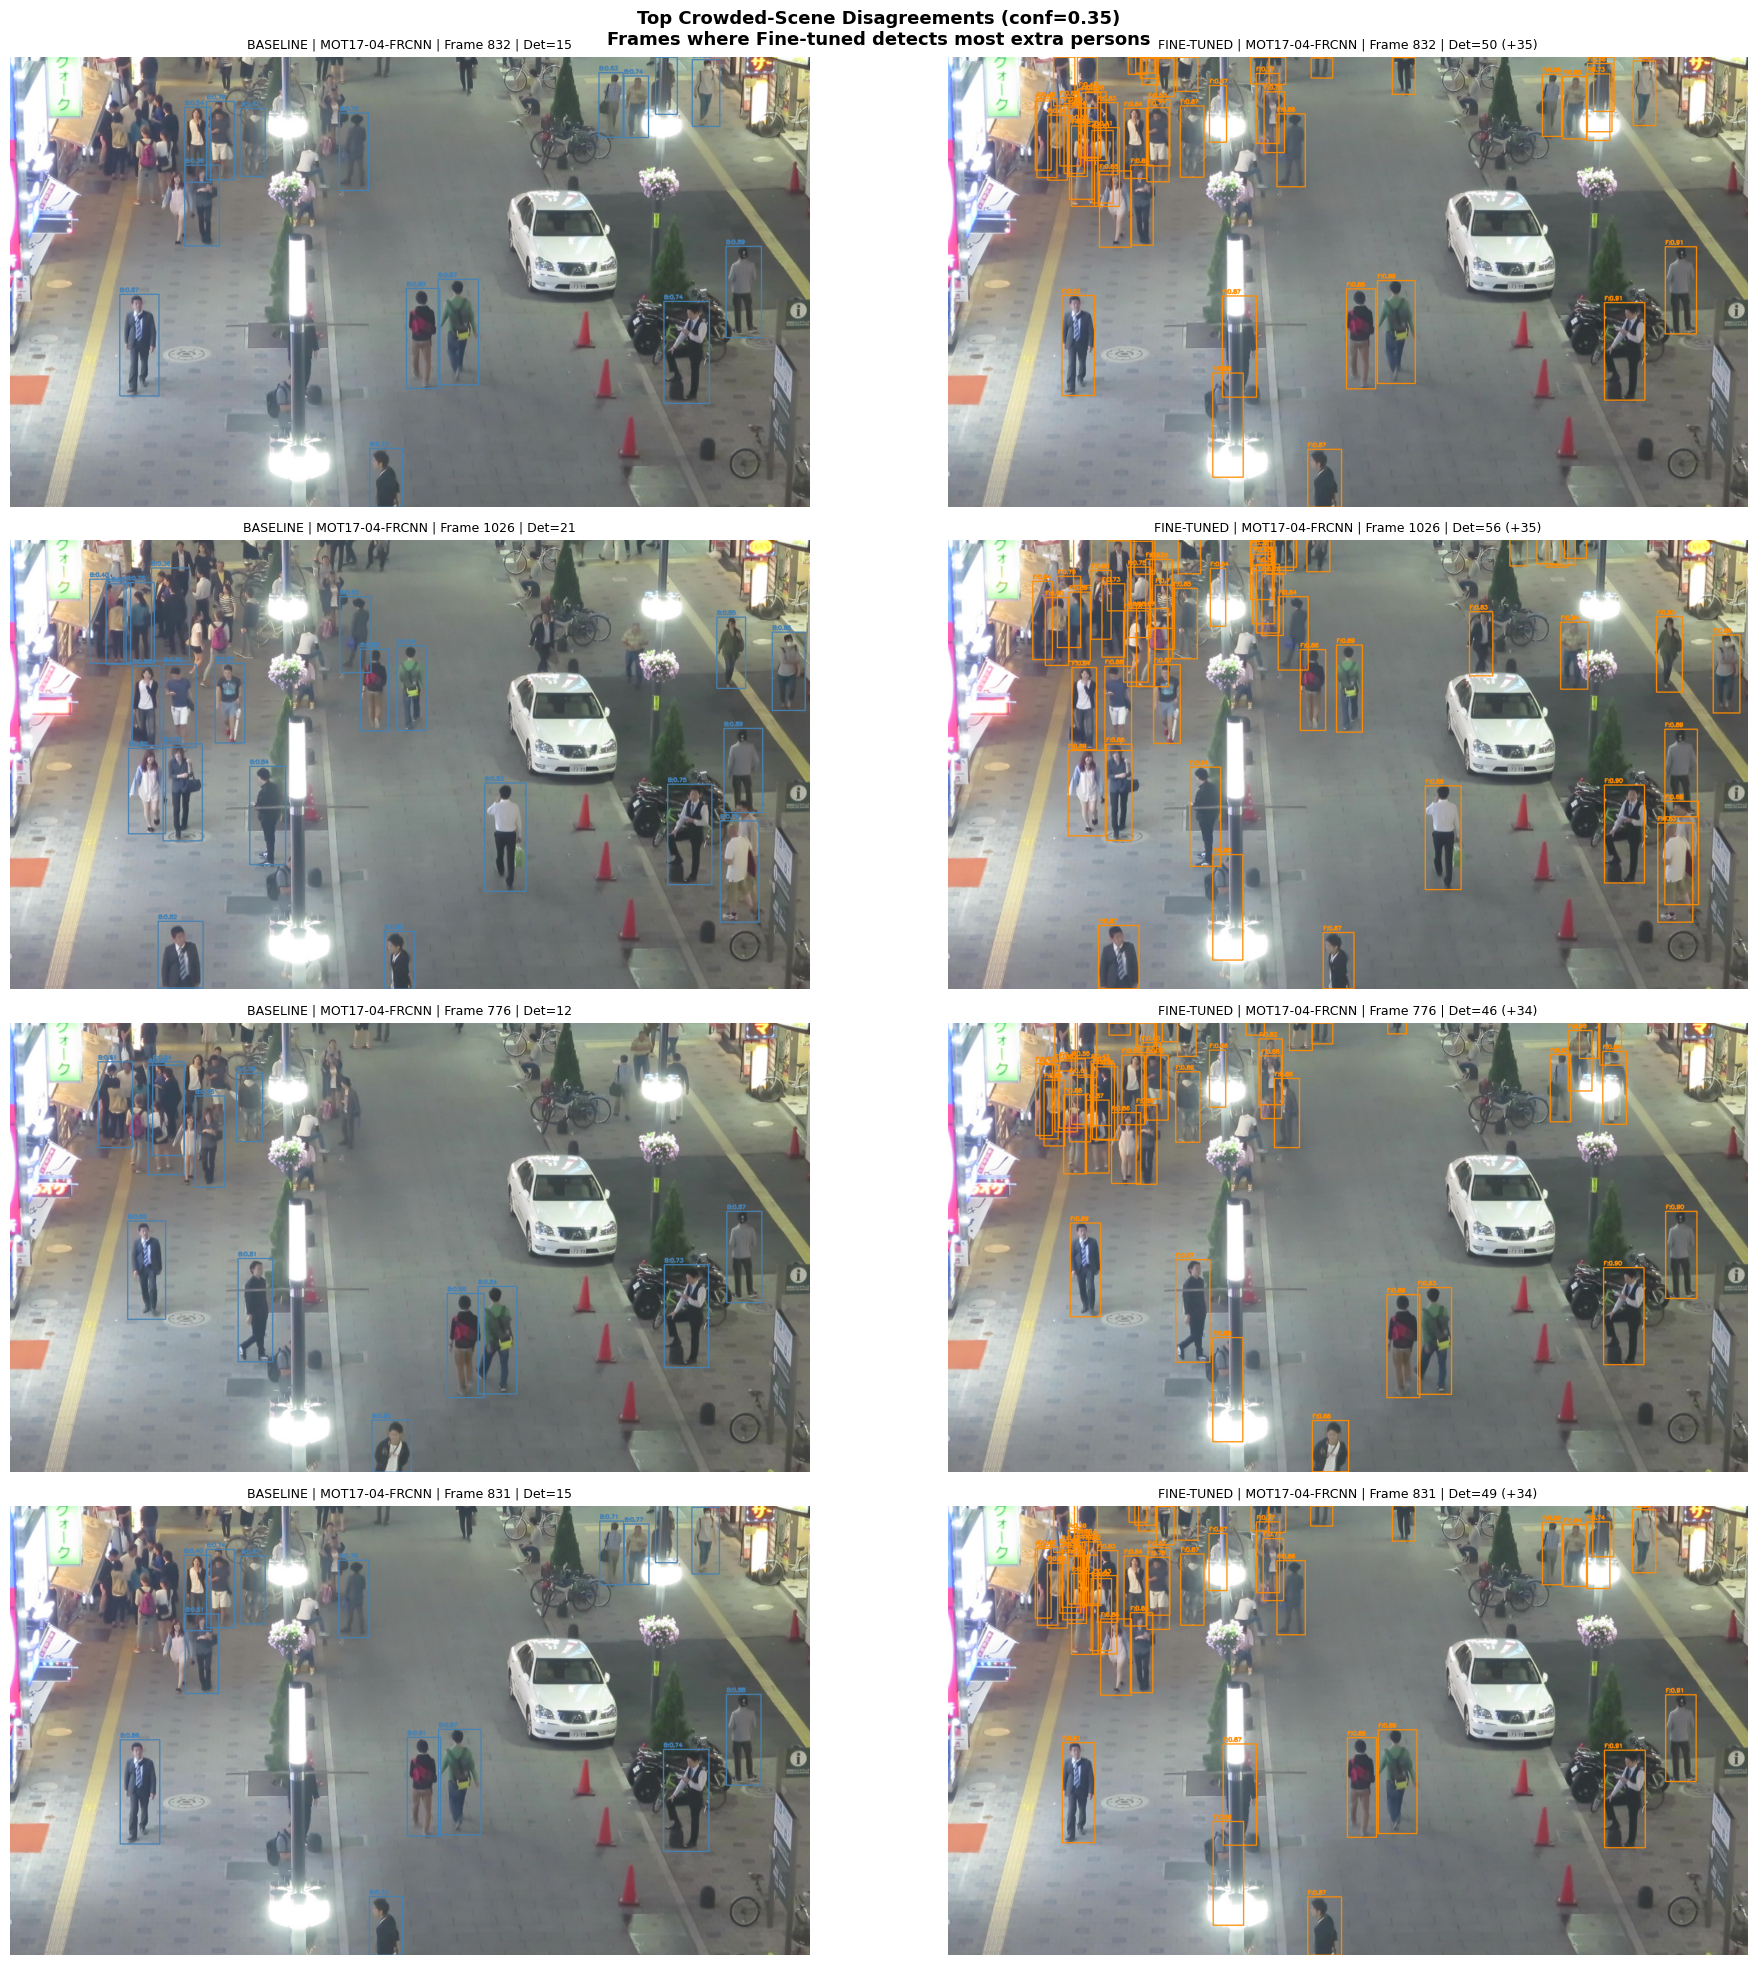

Saved sample image to: outputs/crowded_comparison\side_by_side_samples.png


In [6]:
def annotate_frame(frame, boxes, color, prefix=''):
    out = frame.copy()
    for (x1,y1,x2,y2,conf) in boxes:
        cv2.rectangle(out,(x1,y1),(x2,y2),color,2)
        cv2.putText(out,f'{prefix}{conf:.2f}',(x1,max(0,y1-6)),
                    cv2.FONT_HERSHEY_SIMPLEX,0.45,color,2)
    return out

rec_b_v, frm_b_v, pth_b_v = results_store[VIS_THRESH]['baseline']
rec_f_v, frm_f_v, pth_f_v = results_store[VIS_THRESH]['finetuned']

# If frames were cached (VIS_THRESH run), use them; else read from disk
def get_frame(cached_list, img_path_list, idx):
    if cached_list:
        return cached_list[idx].copy()
    return cv2.imread(str(img_path_list[idx]))

# Rank by detection difference
diffs = [(i, rec_f_v[i]['count']-rec_b_v[i]['count'],
          rec_f_v[i]['count'], rec_b_v[i]['count'])
         for i in range(len(rec_b_v))]
diffs.sort(key=lambda x: -x[1])
top4 = diffs[:4]

print(f'Top disagreement frames (conf={VIS_THRESH}):')
for idx,diff,cf,cb in top4:
    print(f'  idx={idx:5d} | seq={rec_b_v[idx]["seq"]} | '
          f'baseline={cb} fine-tuned={cf} (+{diff})')

COLOR_BV = (180,130,70)
COLOR_FV = (0,140,255)

fig, axes = plt.subplots(len(top4), 2, figsize=(20, 5*len(top4)))
if len(top4)==1: axes=[axes]

for row_ax,(idx,diff,cf,cb) in zip(axes,top4):
    fb = get_frame(frm_b_v, pth_b_v, idx)
    ff = get_frame(frm_f_v, pth_f_v, idx)
    ann_b = annotate_frame(fb, rec_b_v[idx]['boxes'], COLOR_BV, 'B:')
    ann_f = annotate_frame(ff, rec_f_v[idx]['boxes'], COLOR_FV, 'F:')

    row_ax[0].imshow(cv2.cvtColor(ann_b,cv2.COLOR_BGR2RGB))
    row_ax[0].set_title(f'BASELINE | {rec_b_v[idx]["seq"]} | '
                        f'Frame {rec_b_v[idx]["frame_id"]} | Det={cb}', fontsize=9)
    row_ax[0].axis('off')
    row_ax[1].imshow(cv2.cvtColor(ann_f,cv2.COLOR_BGR2RGB))
    row_ax[1].set_title(f'FINE-TUNED | {rec_f_v[idx]["seq"]} | '
                        f'Frame {rec_f_v[idx]["frame_id"]} | Det={cf} (+{diff})', fontsize=9)
    row_ax[1].axis('off')

plt.suptitle(f'Top Crowded-Scene Disagreements (conf={VIS_THRESH})\n'
             'Frames where Fine-tuned detects most extra persons',
             fontsize=13, fontweight='bold')
plt.tight_layout()
out = os.path.join(OUTPUT_DIR,'side_by_side_samples.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Saved sample image to:', out)

## 7) GT-Based Before/After Bar Chart

Official Precision / Recall / mAP from crowdedCondition.ipynb validation —
stronger evidence than the det/frame proxy because MOT17 has real ground truth.

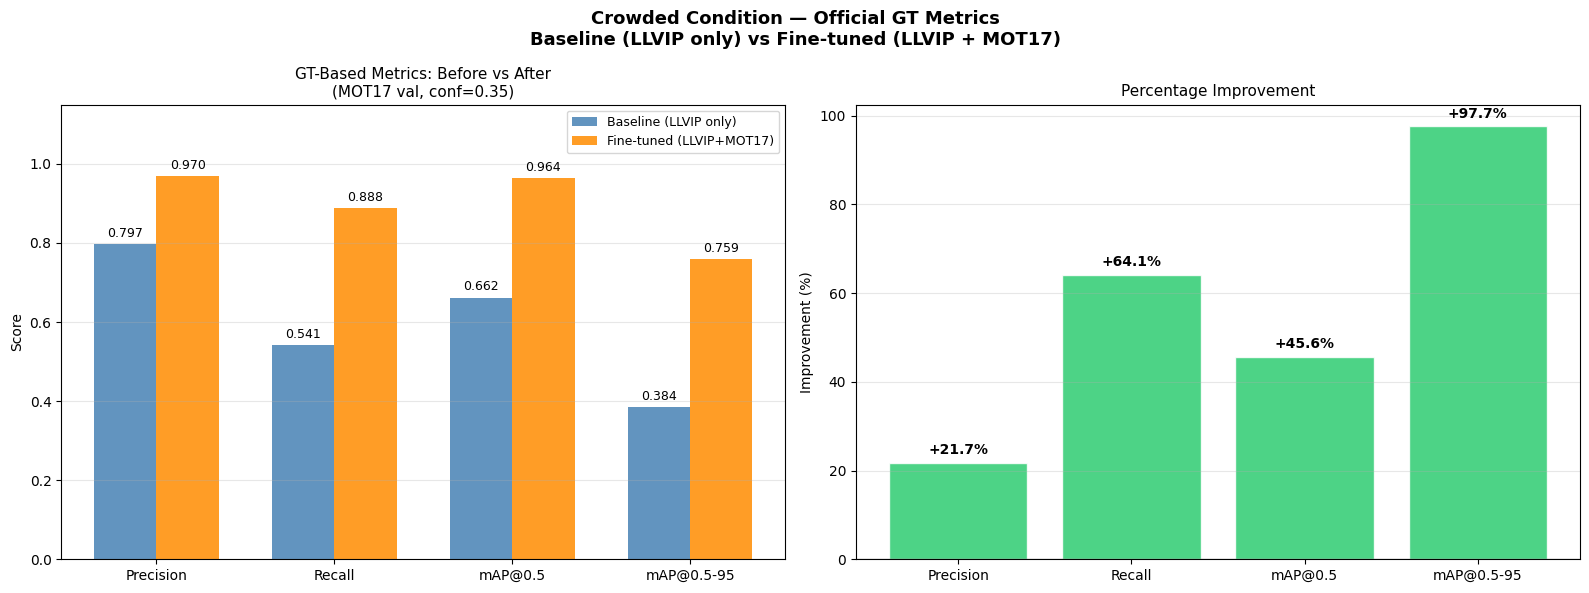

Saved GT bar chart to: outputs/crowded_comparison\gt_metrics_comparison.png


In [7]:
BEFORE = {'Precision':0.797,'Recall':0.541,'mAP@0.5':0.662,'mAP@0.5-95':0.384}
AFTER  = {'Precision':0.970,'Recall':0.888,'mAP@0.5':0.964,'mAP@0.5-95':0.759}

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(16,6))

names = list(BEFORE.keys())
bv = list(BEFORE.values()); av = list(AFTER.values())
x  = np.arange(len(names)); w = 0.35

bb = ax1.bar(x-w/2, bv, w, label='Baseline (LLVIP only)',    color='steelblue',  alpha=0.85)
bf = ax1.bar(x+w/2, av, w, label='Fine-tuned (LLVIP+MOT17)', color='darkorange', alpha=0.85)
ax1.bar_label(bb, fmt='%.3f', padding=3, fontsize=9)
ax1.bar_label(bf, fmt='%.3f', padding=3, fontsize=9)
ax1.set_xticks(x); ax1.set_xticklabels(names, fontsize=10)
ax1.set_ylabel('Score'); ax1.set_ylim(0,1.15)
ax1.set_title('GT-Based Metrics: Before vs After\n(MOT17 val, conf=0.35)', fontsize=11)
ax1.legend(fontsize=9); ax1.grid(axis='y',alpha=0.3)

impr = [(av[i]-bv[i])/max(bv[i],1e-6)*100 for i in range(len(names))]
colors = ['#2ecc71' if v>=0 else '#e74c3c' for v in impr]
bi = ax2.bar(names,impr,color=colors,alpha=0.85,edgecolor='white')
ax2.bar_label(bi,labels=[f'+{v:.1f}%' for v in impr],padding=4,fontsize=10,fontweight='bold')
ax2.axhline(0,color='black',linewidth=0.8)
ax2.set_ylabel('Improvement (%)'); ax2.set_title('Percentage Improvement',fontsize=11)
ax2.grid(axis='y',alpha=0.3)

plt.suptitle('Crowded Condition — Official GT Metrics\n'
             'Baseline (LLVIP only) vs Fine-tuned (LLVIP + MOT17)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
out = os.path.join(OUTPUT_DIR,'gt_metrics_comparison.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Saved GT bar chart to:', out)

## 8) Threshold Recommendation Bar Chart

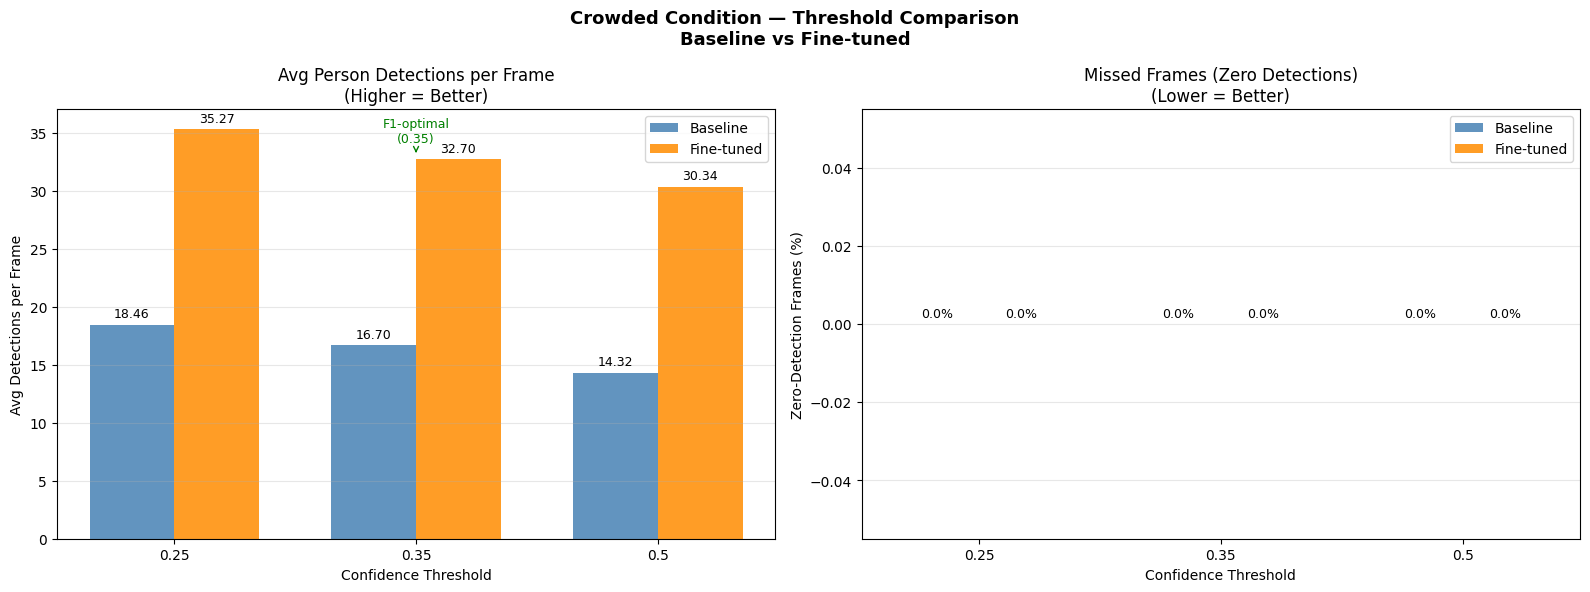

>>> Recommended threshold for deployment: 0.5
    Improvement at this threshold: +111.9%


In [8]:
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(16,6))
x = np.arange(len(THRESHOLDS)); w = 0.35
avg_b_l,avg_f_l,z_b_l,z_f_l = [],[],[],[]

for thresh in THRESHOLDS:
    rb,_,_ = results_store[thresh]['baseline']
    rf,_,_ = results_store[thresh]['finetuned']
    cb = [r['count'] for r in rb]; cf = [r['count'] for r in rf]
    avg_b_l.append(np.mean(cb)); avg_f_l.append(np.mean(cf))
    z_b_l.append(100*sum(1 for c in cb if c==0)/len(cb))
    z_f_l.append(100*sum(1 for c in cf if c==0)/len(cf))

bb=ax1.bar(x-w/2,avg_b_l,w,label='Baseline',   color='steelblue',  alpha=0.85)
bf=ax1.bar(x+w/2,avg_f_l,w,label='Fine-tuned', color='darkorange', alpha=0.85)
ax1.bar_label(bb,fmt='%.2f',padding=3,fontsize=9)
ax1.bar_label(bf,fmt='%.2f',padding=3,fontsize=9)
ax1.set_xlabel('Confidence Threshold'); ax1.set_ylabel('Avg Detections per Frame')
ax1.set_title('Avg Person Detections per Frame\n(Higher = Better)')
ax1.set_xticks(x); ax1.set_xticklabels([str(t) for t in THRESHOLDS])
ax1.legend(); ax1.grid(axis='y',alpha=0.3)
if 0.35 in THRESHOLDS:
    oi=THRESHOLDS.index(0.35); ymax=max(avg_b_l[oi],avg_f_l[oi])
    ax1.annotate('F1-optimal\n(0.35)',xy=(oi,ymax+0.3),xytext=(oi,ymax+1.5),
                 ha='center',fontsize=9,color='green',
                 arrowprops=dict(arrowstyle='->',color='green'))

bb2=ax2.bar(x-w/2,z_b_l,w,label='Baseline',   color='steelblue',  alpha=0.85)
bf2=ax2.bar(x+w/2,z_f_l,w,label='Fine-tuned', color='darkorange', alpha=0.85)
ax2.bar_label(bb2,fmt='%.1f%%',padding=3,fontsize=9)
ax2.bar_label(bf2,fmt='%.1f%%',padding=3,fontsize=9)
ax2.set_xlabel('Confidence Threshold'); ax2.set_ylabel('Zero-Detection Frames (%)')
ax2.set_title('Missed Frames (Zero Detections)\n(Lower = Better)')
ax2.set_xticks(x); ax2.set_xticklabels([str(t) for t in THRESHOLDS])
ax2.legend(); ax2.grid(axis='y',alpha=0.3)

plt.suptitle('Crowded Condition — Threshold Comparison\nBaseline vs Fine-tuned',
             fontsize=13,fontweight='bold')
plt.tight_layout()
out=os.path.join(OUTPUT_DIR,'threshold_comparison_bars.png')
plt.savefig(out,dpi=150,bbox_inches='tight')
plt.show()

best_i=int(np.argmax([(avg_f_l[i]-avg_b_l[i])/max(avg_b_l[i],1e-6) for i in range(len(THRESHOLDS))]))
imp_best=(avg_f_l[best_i]-avg_b_l[best_i])/max(avg_b_l[best_i],1e-6)*100
print(f'>>> Recommended threshold for deployment: {THRESHOLDS[best_i]}')
print(f'    Improvement at this threshold: +{imp_best:.1f}%')

## 9) Final Printed Report

In [12]:
print('='*62)
print('  CROWDED CONDITION EVALUATION SUMMARY')
print('  Baseline (LLVIP only) vs Fine-tuned (LLVIP + MOT17)')
print('='*62)
print(f'  Sequences : {", ".join(VAL_SEQUENCES)}')
total_frames=len(results_store[THRESHOLDS[0]]['baseline'][0])
print(f'  Frames    : {total_frames}')
print()

for thresh in THRESHOLDS:
    rec_b,_,_=results_store[thresh]['baseline']
    rec_f,_,_=results_store[thresh]['finetuned']
    cb=[r['count'] for r in rec_b]; cf=[r['count'] for r in rec_f]
    imp=(np.mean(cf)-np.mean(cb))/max(np.mean(cb),1e-6)*100
    miss_b=sum(1 for c in cb if c==0)
    miss_f=sum(1 for c in cf if c==0)
    marker=' ◄ F1-optimal' if thresh==0.35 else ''
    print(f'  Threshold = {thresh}{marker}')
    print(f'    Baseline   — avg: {np.mean(cb):.3f} det/frame | zero-det: {miss_b} ({100*miss_b/len(cb):.1f}%)')
    print(f'    Fine-tuned — avg: {np.mean(cf):.3f} det/frame | zero-det: {miss_f} ({100*miss_f/len(cf):.1f}%)')
    print(f'    Improvement: {("+" if imp>=0 else "")}{imp:.1f}%')
    print()
print()
print('  Final model path (use in pipeline):')
print(f'  {FINETUNED_WEIGHTS}')

  CROWDED CONDITION EVALUATION SUMMARY
  Baseline (LLVIP only) vs Fine-tuned (LLVIP + MOT17)
  Sequences : MOT17-04-FRCNN, MOT17-09-FRCNN
  Frames    : 1575

  Threshold = 0.25
    Baseline   — avg: 18.457 det/frame | zero-det: 0 (0.0%)
    Fine-tuned — avg: 35.269 det/frame | zero-det: 0 (0.0%)
    Improvement: +91.1%

  Threshold = 0.35 ◄ F1-optimal
    Baseline   — avg: 16.703 det/frame | zero-det: 0 (0.0%)
    Fine-tuned — avg: 32.697 det/frame | zero-det: 0 (0.0%)
    Improvement: +95.8%

  Threshold = 0.5
    Baseline   — avg: 14.319 det/frame | zero-det: 0 (0.0%)
    Fine-tuned — avg: 30.335 det/frame | zero-det: 0 (0.0%)
    Improvement: +111.9%


  Final model path (use in pipeline):
  runs\detect\runs\crowdedCondition_yolo\runs\yolov8_mot17_finetune_from_llvip\weights\best.pt


In [11]:
BEFORE = {'Precision':0.797,'Recall':0.541,'mAP@0.5':0.662,'mAP@0.5-95':0.384}
AFTER  = {'Precision':0.970,'Recall':0.888,'mAP@0.5':0.964,'mAP@0.5-95':0.759}

print('='*62)
print('  GT-BASED METRICS (crowdedCondition.ipynb validation)')
print('='*62)
print(f'  {"Metric":<14} {"BEFORE":>8} {"AFTER":>8} {"Change":>9}')
print(f'  {"-"*44}')
for k in BEFORE:
    b=BEFORE[k]; a=AFTER[k]; ch=a-b; sign='+' if ch>=0 else ''
    print(f'  {k:<14} {b:>8.3f} {a:>8.3f} {sign}{ch:>+8.3f}')
print('='*62)


  GT-BASED METRICS (crowdedCondition.ipynb validation)
  Metric           BEFORE    AFTER    Change
  --------------------------------------------
  Precision         0.797    0.970 +  +0.173
  Recall            0.541    0.888 +  +0.347
  mAP@0.5           0.662    0.964 +  +0.302
  mAP@0.5-95        0.384    0.759 +  +0.375
